In [89]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import time


# GRIDWORLD ENVIRONMENT


In [90]:
class GridWorldEnv(gym.Env):
    def __init__(self, size=4, stochastic=False, obstacles=None):
        super().__init__()
        self.size = size
        self.nS = size * size
        self.nA = 4
        self.stochastic = stochastic
        self.obstacles = obstacles if obstacles else []

        self.action_space = spaces.Discrete(self.nA)
        self.observation_space = spaces.Discrete(self.nS)

        self.terminals = [0, self.nS - 1]
        self.P = self.build_P()

    def to_state(self, r, c):
        return r * self.size + c

    def to_pos(self, s):
        return divmod(s, self.size)

    def build_P(self):
        P = {s: {a: [] for a in range(self.nA)} for s in range(self.nS)}
        directions = [(-1,0),(0,1),(1,0),(0,-1)]

        def move(r, c, a):
            dr, dc = directions[a]
            nr = max(0, min(self.size-1, r+dr))
            nc = max(0, min(self.size-1, c+dc))
            if (nr, nc) in self.obstacles:
                return self.to_state(r, c)
            return self.to_state(nr, nc)

        for s in range(self.nS):
            r, c = self.to_pos(s)
            for a in range(self.nA):

                if s in self.terminals:
                    P[s][a] = [(1.0, s, 0, True)]
                    continue

                if not self.stochastic:
                    ns = move(r, c, a)
                    P[s][a] = [(1.0, ns, -1, ns in self.terminals)]
                else:
                    transitions = [(0.8, a), (0.1, (a+1)%4), (0.1, (a-1)%4)]
                    for prob, act in transitions:
                        ns = move(r, c, act)
                        P[s][a].append((prob, ns, -1, ns in self.terminals))

        return P


# POLICY EVALUATION

In [91]:
def policy_evaluation(env, policy, gamma=0.9, theta=1e-6, inplace=False):
    V = np.zeros(env.nS)
    history = []

    while True:
        delta = 0
        V_new = V.copy()

        for s in range(env.nS):
            v = 0
            for a in range(env.nA):
                for prob, ns, r, done in env.P[s][a]:
                    v += policy[s][a] * prob * (r + gamma * V[ns] * (not done))

            if inplace:
                delta = max(delta, abs(V[s] - v))
                V[s] = v
            else:
                delta = max(delta, abs(V_new[s] - v))
                V_new[s] = v

        if not inplace:
            V = V_new

        history.append(V.copy())

        if delta < theta:
            break

    return V, history


# Policy Improvement

In [92]:
def policy_improvement(env, V, old_policy, gamma=0.9):
    policy = np.zeros((env.nS, env.nA))
    stable = True

    for s in range(env.nS):
        q = np.zeros(env.nA)

        for a in range(env.nA):
            for prob, ns, r, done in env.P[s][a]:
                q[a] += prob * (r + gamma * V[ns] * (not done))

        best_a = np.argmax(q)
        policy[s][best_a] = 1

        if not np.array_equal(policy[s], old_policy[s]):
            stable = False

    return policy, stable


# POLICY ITERATION


In [93]:
def policy_iteration(env, inplace_eval=False):
    policy = np.ones((env.nS, env.nA)) / env.nA
    history = []
    iterations = 0

    while True:
        V, eval_hist = policy_evaluation(env, policy, inplace=inplace_eval)
        history.extend(eval_hist)

        new_policy, stable = policy_improvement(env, V, policy)
        policy = new_policy

        iterations += 1

        if stable:
            break

    return policy, V, history, iterations

# VALUE ITERATION (SYNC)


In [94]:
def value_iteration(env, gamma=0.9, theta=1e-6):
    V = np.zeros(env.nS)
    history = []
    deltas = []

    while True:
        delta = 0
        V_new = V.copy()

        for s in range(env.nS):
            q = np.zeros(env.nA)
            for a in range(env.nA):
                for prob, ns, r, done in env.P[s][a]:
                    q[a] += prob * (r + gamma * V[ns] * (not done))

            V_new[s] = np.max(q)
            delta = max(delta, abs(V[s] - V_new[s]))

        V = V_new
        history.append(V.copy())
        deltas.append(delta)

        if delta < theta:
            break

    policy, _ = policy_improvement(env, V, np.zeros((env.nS, env.nA)))
    return policy, V, history, deltas


# VALUE ITERATION (IN-PLACE)


In [95]:
def value_iteration_inplace(env, gamma=0.9, theta=1e-6):
    V = np.zeros(env.nS)
    history = []
    deltas = []

    while True:
        delta = 0

        for s in range(env.nS):
            v = V[s]
            q = np.zeros(env.nA)

            for a in range(env.nA):
                for prob, ns, r, done in env.P[s][a]:
                    q[a] += prob * (r + gamma * V[ns] * (not done))

            V[s] = np.max(q)
            delta = max(delta, abs(v - V[s]))

        history.append(V.copy())
        deltas.append(delta)

        if delta < theta:
            break

    policy, _ = policy_improvement(env, V, np.zeros((env.nS, env.nA)))
    return policy, V, history, deltas


# VISUALIZATION


In [96]:
def plot_heatmap(V, size, title):
    plt.imshow(V.reshape(size, size))
    plt.title(title)
    plt.colorbar()
    plt.show()


def plot_policy(policy, size, title):
    dx = np.zeros((size, size))
    dy = np.zeros((size, size))
    directions = {0:(-1,0),1:(0,1),2:(1,0),3:(0,-1)}

    for s in range(size*size):
        r, c = divmod(s, size)
        a = np.argmax(policy[s])
        dy[r,c], dx[r,c] = directions[a]

    plt.quiver(dx, -dy)
    plt.title(title)
    plt.show()


def plot_convergence(deltas, label):
    plt.plot(deltas, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Delta")
    plt.legend()


# EXPERIMENT RUNNER

In [97]:
def run_experiment(env, name):
    print(f"\n===== {name} =====")

    # Policy Iteration (sync)
    start = time.time()
    pi_policy, pi_V, _, pi_iter = policy_iteration(env, inplace_eval=False)
    pi_time = time.time() - start

    # Policy Iteration (in-place)
    start = time.time()
    pi_policy_in, pi_V_in, _, pi_iter_in = policy_iteration(env, inplace_eval=True)
    pi_time_in = time.time() - start

    # Value Iteration (sync)
    start = time.time()
    vi_policy, V_vi, _, deltas = value_iteration(env)
    vi_time = time.time() - start

    # Value Iteration (in-place)
    start = time.time()
    vi_policy_in, V_vi_in, _, deltas_in = value_iteration_inplace(env)
    vi_time_in = time.time() - start

    # ======================
    # COMPARISON OUTPUT
    # ======================
    print("\n--- Comparison ---")
    print(f"PI Sync: Iter={pi_iter}, Time={pi_time:.4f}s")
    print(f"PI In-place: Iter={pi_iter_in}, Time={pi_time_in:.4f}s")
    print(f"VI Sync: Iter={len(deltas)}, Time={vi_time:.4f}s")
    print(f"VI In-place: Iter={len(deltas_in)}, Time={vi_time_in:.4f}s")

    # ======================
    # VISUALIZATION
    # ======================
    plot_heatmap(V_vi, env.size, name + " Value Function")

    plot_policy(vi_policy, env.size, name + " Policy")

    plt.figure()
    plot_convergence(deltas, "VI Sync")
    plot_convergence(deltas_in, "VI In-place")
    plt.title(name + " Convergence")
    plt.show()

# FROZENLAKE


In [98]:
def run_frozenlake():
    import gymnasium as gym

    env = gym.make("FrozenLake-v1", is_slippery=True)

    env = env.unwrapped

    env.nS = env.observation_space.n
    env.nA = env.action_space.n
    env.P = env.P  # already exists, but keeps consistency

    # Run Value Iteration
    policy, V, _, _ = value_iteration(env)

    print("\nFrozenLake Value Function:")
    print(V.reshape(4,4))

# Main


===== Deterministic =====

--- Comparison ---
PI Sync: Iter=3, Time=0.0235s
PI In-place: Iter=3, Time=0.0168s
VI Sync: Iter=4, Time=0.0023s
VI In-place: Iter=4, Time=0.0024s


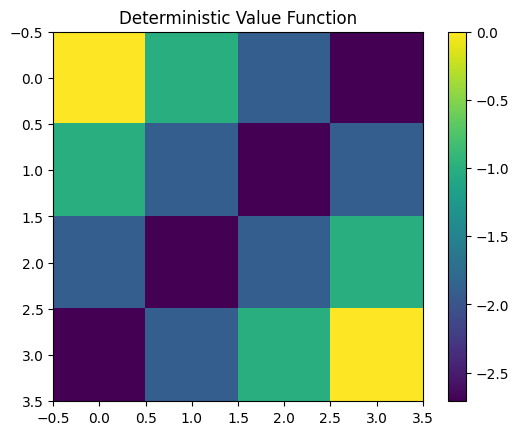

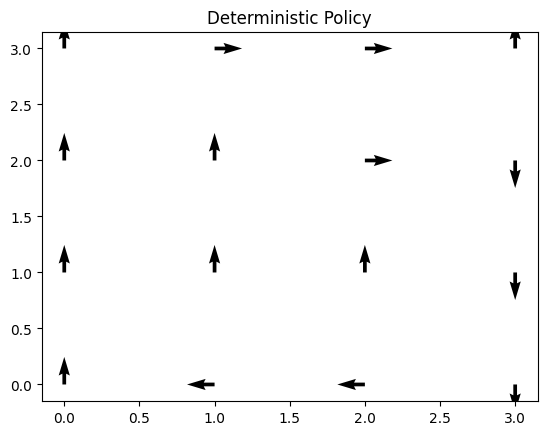

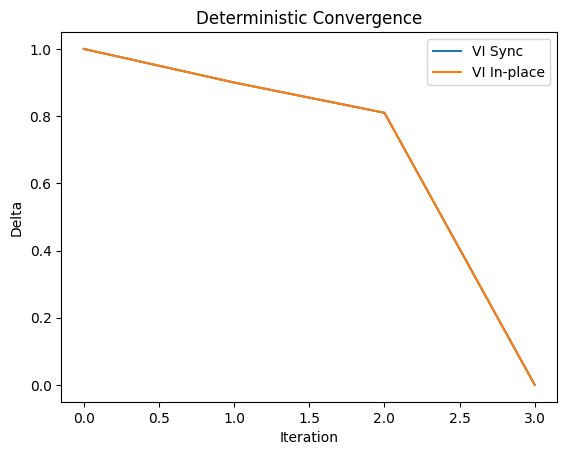


===== Stochastic =====

--- Comparison ---
PI Sync: Iter=3, Time=0.0746s
PI In-place: Iter=3, Time=0.0329s
VI Sync: Iter=19, Time=0.0097s
VI In-place: Iter=13, Time=0.0082s


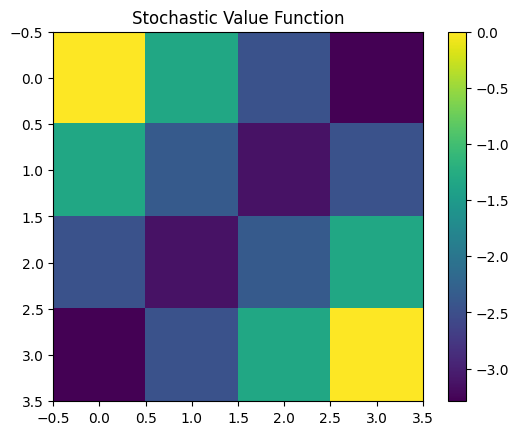

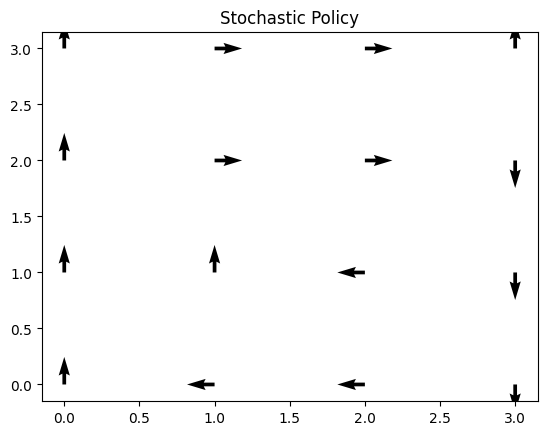

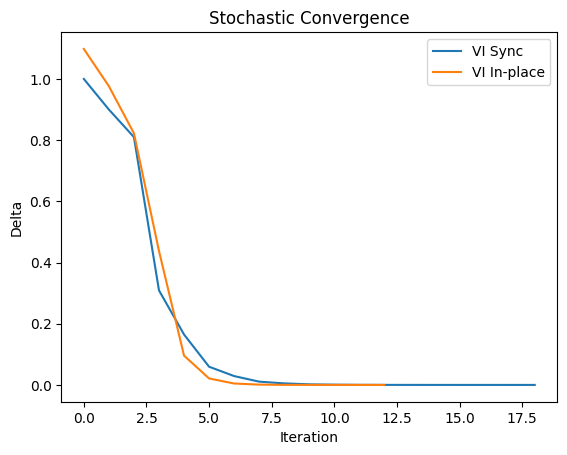


FrozenLake Value Function:
[[0.06888466 0.06140928 0.07440591 0.05580308]
 [0.09184887 0.         0.11220613 0.        ]
 [0.14543176 0.24749386 0.29961541 0.        ]
 [0.         0.37993367 0.63901898 0.        ]]


In [99]:
if __name__ == "__main__":
    env_det = GridWorldEnv(size=4, stochastic=False)
    env_stoch = GridWorldEnv(size=4, stochastic=True)

    run_experiment(env_det, "Deterministic")
    run_experiment(env_stoch, "Stochastic")

    run_frozenlake()